In [1]:
import os
import cv2
import shutil
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow import keras
from torchvision import transforms
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

## CNN Model Creation
The following function builds the basic CNN model that will be used as a "benchmark" model to compare how data impacts the results of the prediction model. The model consists of three convolutional layers, each followed by max-pooling to downsample features.
A fully connected dense layer helps learn patterns before the final classification layer.
The softmax output layer assigns probabilities for normal vs pneumonia classification.

In [2]:
def create_cnn(input_shape=(224, 224, 1), num_classes=1):
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        # Conv Block 2
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        # Conv Block 3
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        # Flatten
        layers.Flatten(),

        # Fully Connected Layers with Dropout
        layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4),

        layers.Dense(64, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Output Layer
        layers.Dense(num_classes, activation='sigmoid')
    ])

    # Compile with accuracy, precision, recall metrics
    optimizer = Adam(learning_rate=0.0001)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', 'recall', 'precision']
    )

    return model

## Load Dataset
The following function is important for the CNN processing pipeline. This function loads in the dataset, resizes the images so they are all the same size and can be processed by the model correctly. This function also converts the images to grayscale. Some of the images are saturated or really washed out, which might impact model performance, applying grayscale helps mitigate this.

In [11]:
# Function to load dataset dynamically
def load_dataset(data_filepath, img_size=(224, 224), batch_size=16):
    # Create an ImageDataGenerator instance with desired preprocessing steps
    # datagen = ImageDataGenerator(
    #     rescale=1./255,
    #     rotation_range=20, # Randomly rotate images up to 20 degrees
    #     # width_shift_range=0.2, # Randomly shift images horizontally
    #     # height_shift_range=0.2, # Randomly shift images vertically
    #     # shear_range=0.2, # Apply random shearing transformations
    #     # zoom_range=0.2, # Randomly zoom in/out
    #     horizontal_flip=True, # Randomly flip images horizontally
    #     # fill_mode='nearest', # Fill in missing pixels
    #     brightness_range=[0.8, 1.2] # Add Brightness adjustment
    #     # preprocessing_function=gaussian_blur # Apply Gaussian Blur
    # )
    datagen = ImageDataGenerator(
      rescale=1./255,
      # rotation_range=30,
      # width_shift_range=0.3,
      # height_shift_range=0.3,
      shear_range=0.3,
      # zoom_range=0.3,
      horizontal_flip=True,
      brightness_range=[0.7, 1.3]
  )

    # datagen = ImageDataGenerator()


    # Create a flow_from_directory for the dataset
    dataset = datagen.flow_from_directory(
        data_filepath,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        color_mode='grayscale',
      )

    return dataset

In [22]:
def load_and_balance_dataset(data_filepath, img_size=(150,150), batch_size=32):
    # Load all image paths and labels
    image_paths = []
    labels = []
    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_path = os.path.join(data_filepath, class_name)
        for image_name in os.listdir(class_path):
            image_paths.append(os.path.join(class_path, image_name))
            labels.append(class_name)

    # Separate paths by class
    normal_paths = [path for path, label in zip(image_paths, labels) if label == "NORMAL"]
    pneumonia_paths = [path for path, label in zip(image_paths, labels) if label == "PNEUMONIA"]

    # Undersample the majority class (PNEUMONIA)
    num_normal = len(normal_paths)
    pneumonia_paths = random.sample(pneumonia_paths, num_normal)  # Undersample to match NORMAL count

    # Combine paths and labels for the balanced dataset
    balanced_paths = normal_paths + pneumonia_paths
    balanced_labels = ['NORMAL'] * num_normal + ['PNEUMONIA'] * num_normal

    datagen = ImageDataGenerator(
      rescale=1./255,
      shear_range=0.3,
      horizontal_flip=True,
      brightness_range=[0.7, 1.3]
  )

    # Create flow_from_dataframe using balanced data
    df = pd.DataFrame({'filename': balanced_paths, 'class': balanced_labels})
    dataset = datagen.flow_from_dataframe(
        dataframe=df,
        directory=None,
        x_col="filename",
        y_col="class",
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        color_mode='grayscale'
    )

    return dataset


In [4]:
def copy_files(file_list, destination):
    for file in file_list:
        shutil.copy(file, destination)

def load_and_split_dataset(data_dir, output_dir):
  # Create output directories
  for split in ["train", "val"]:
      for cls in ["NORMAL", "PNUEMONIA"]:
          os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

  # Load all images into a dictionary
  data = {"NORMAL": [], "PNUEMONIA": []}
  for cls in data.keys():
      cls_path = os.path.join(data_dir, cls)
      data[cls] = [os.path.join(cls_path, img) for img in os.listdir(cls_path) if img.endswith(('.png', '.jpg', '.jpeg'))]

  # Split data (80% train, 20% val)
  train_data, val_data = train_test_split(data["NORMAL"], test_size=0.2, random_state=42)
  train_data_1, val_data_1 = train_test_split(data["PNUEMONIA"], test_size=0.2, random_state=42)


  # Copy images to respective directories
  copy_files(train_data, os.path.join(output_dir, "train/NORMAL"))
  copy_files(val_data, os.path.join(output_dir, "val/NORMAL"))

  copy_files(train_data_1, os.path.join(output_dir, "train/PNUEMONIA"))
  copy_files(val_data_1, os.path.join(output_dir, "val/PNUEMONIA"))

  print("Dataset successfully split into training and validation sets!")



## Model Training and Evaluation
The following function trains the CNN model that is defined above. Once the model is trained, the metrics (accuracy, precision, recall and f1) are extracted from the model. The precision and recall metrics are important in addition to accuracy because of the large class imbalance in this dataset. These are good metrics to compare model performance against different input data configurations. These metrics are written to a named csv file that can be referenced later, and also used for plotting the results.

In [5]:
# Function to train and evaluate the model
def train_and_evaluate(model, train_ds, val_ds, test_ds, test_description="example_test"):
    results_path = f"{test_description}_results.csv"

    # Callbacks for training
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, verbose=1)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        # class_weight=class_weight,
        callbacks=[lr_scheduler, early_stopping]
      )

    # Reset test_ds generator before evaluating
    test_ds.reset()

    # Get total number of steps/batches in test_ds
    steps = test_ds.samples // test_ds.batch_size
    if test_ds.samples % test_ds.batch_size:
        steps += 1

    # Predictions for base CNN model
    y_true, y_pred = [], []
    for i in range(steps):
        images, labels = next(test_ds)
        predictions = model.predict(images)
        binary_preds = (predictions > 0.6).astype(int).flatten()
        # binary_preds = np.argmax(predictions, axis=1)
        y_true.extend(labels.astype(int))
        # y_true.extend(np.argmax(labels, axis=1))
        y_pred.extend(binary_preds)

    # Convert to numpy arrays for metric calculations
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    # Per-class metrics
    report = classification_report(y_true, y_pred, output_dict=True)
    class_0_precision = report['0.0']['precision'] if '0.0' in report else report['0']['precision']
    class_0_recall = report['0.0']['recall'] if '0.0' in report else report['0']['recall']
    class_1_precision = report['1.0']['precision'] if '1.0' in report else report['1']['precision']
    class_1_recall = report['1.0']['recall'] if '1.0' in report else report['1']['recall']

    # Update your results dataframe with more detailed metrics
    results_df = pd.DataFrame({
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1],
        'Class_0_Precision': [class_0_precision],
        'Class_0_Recall': [class_0_recall],
        'Class_1_Precision': [class_1_precision],
        'Class_1_Recall': [class_1_recall]
    })

    results_df.to_csv(results_path, index=False)
    print("Metrics saved to", results_path)
    print(classification_report(y_true, y_pred))
    return history, y_true, y_pred, results_df

## Results
The following function creates 3 different plots to show the metrics for training and validation. The first plot is the training and validation accuracy comparison. The second plot is the loss function for training and testing and the final plot shows the recall metrics.

In [6]:
# Function to visualize results
def plot_results(history, y_true, y_pred, test_description):
    # accuracy metric
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.title('Training & Validation Accuracy')
    plt.savefig(f"{test_description}_accuracy.png")

    # loss function
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Training & Validation Loss')
    plt.savefig(f"{test_description}_loss.png")

    # recall metric
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['recall'], label='Train Recall')
    plt.plot(history.history['val_recall'], label='Val Recall')
    plt.legend()
    plt.title('Training & Validation Recall')
    plt.savefig(f"{test_description}_recall.png")

    plt.show()

### Run CNN
The remaining code blocks run the functions defined above. To change the data being processed, the different settings should be changed here. The dataset path as well as the training, validation and testing datasets can be loaded according to desired test.

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)


100%|██████████| 2.29G/2.29G [00:56<00:00, 43.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [8]:
# Only run first time if data is coming from kagglehub
import shutil
shutil.move(path + "/chest_xray/chest_xray", "./chest_xray")

'./chest_xray'

### Load Train/Test/Validation Datasets (Kaggle)
The following section creates train, test and validation sets that can be used for testing. This section can be updated so the results file is named to fit the test, and the data_path is accurate to what is being test.

In [18]:
data_path = "./chest_xray"
test_description = "full_kaggle_dataset"
train_ds = load_dataset(os.path.join(data_path, "train"))
val_ds = load_dataset(os.path.join(data_path, "val"))
test_ds = load_dataset(os.path.join(data_path, "test"))

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


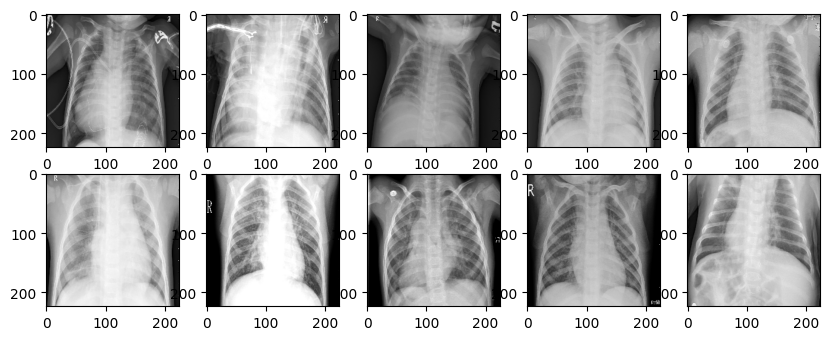

In [19]:
# Visualize first 10 images from train_ds
images, labels = next(iter(train_ds))
plt.figure(figsize=(10,10))
for i in range(10):
    ax = plt.subplot(5,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 67s 177ms/step - accuracy: 0.8921 - loss: 0.6178 - precision: 0.9336 - recall: 0.9174 - val_accuracy: 0.5000 - val_loss: 2.0015 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 56s 171ms/step - accuracy: 0.9582 - loss: 0.4552 - precision: 0.9715 - recall: 0.9723 - val_accuracy: 0.6875 - val_loss: 0.8717 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 56s 172ms/step - accuracy: 0.9639 - loss: 0.3892 - precision: 0.9807 - recall: 0.9710 - val_accuracy: 1.0000 - val_loss: 0.3741 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 56s 172ms/step - accuracy: 0.9620 - loss: 0.3501 - precision: 0.9745 - recall: 0.9744 - val_accuracy: 0.6250 - val_loss: 0.8342 - val_precision: 0.5714 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/30
326/326 ━━━━━━━━━━━━━━━━━

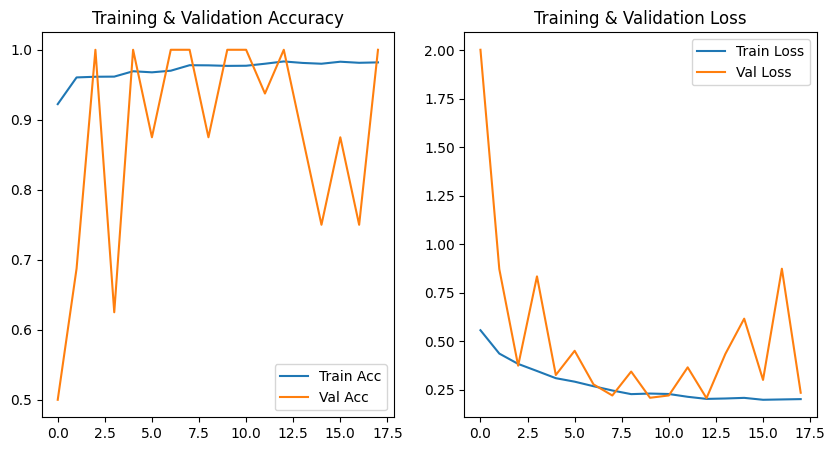

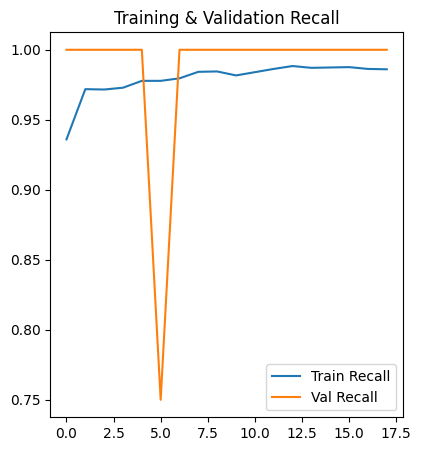

In [20]:
# Train with base cnn model
cnn_model = create_cnn()
test_description = "full_kaggle_base_cnn"
history, y_true, y_pred, results_df = train_and_evaluate(cnn_model, train_ds, val_ds, test_ds, test_description=test_description)
plot_results(history, y_true, y_pred, test_description)

## Balanced Data
The next test uses only the kaggle dataset, but balances it so there is not a majority class like what exists in the actual dataset.

In [23]:
train_ds = load_and_balance_dataset(os.path.join(data_path, "train"))


Found 2682 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


## Different Tests to Try
This section will be used to track the different tests preformed to ensure model training and data testing is going well and we are able to fully understand the impact synthetic data makes on the accuracy and precision and recall of the CNN model for classifying Pneumonia and Normal lungs.

- [ ] Full Kaggle Dataset only (Base CNN)
- [ ] Full Kaggle Dataset only (Transfer learning)
- [ ] Balanced Kaggle Dataset only (Base CNN)
- [ ] Balanced Kaggle Dataset only (Transfer learning)
- [ ] Only Pneumonia Synthetic -- Pawan (Base CNN)
- [ ] Only Pneumonia Synthetic -- Pawan (Transfer Learning)
- [ ] Only Normal Synthetic -- Pawan (Base CNN)
- [ ] Only Normal Synthetic -- Pawan (Transfer Learning)
- [ ] Balanced Synthetic Only -- Pawan (Base CNN)
- [ ] Balanced Synthetic Only -- Pawan (Transfer Learning)
- [ ] Only Pneumonia Synthetic -- Ned (Base CNN)
- [ ] Only Pneumonia Synthetic -- Ned (Transfer Learning)
[ ] Only Normal Synthetic -- Ned (Base CNN)
[ ] Only Normal Synthetic -- Ned (Transfer Learning)
[ ] Balanced Synthetic Only -- Ned (Base CNN)
[ ] Balanced Synthetic Only -- Ned (Transfer Learning)
[ ] Balanced Synthetic and Kaggle Dataset (Base CNN)
[ ] Balanced Synthetic and Kaggle Dataset (Transfer Learning)

## ARC GAN
The following sections loads the ARC GAN images and trains the CNN model using these images. These images are also used for the validation. The test images are from the Kaggle Dataset.

In [12]:
# Split synthetic data into train and validation sets
data_path = "./ARCGAN"
output_path = "./arc_gan"
load_and_split_dataset(data_path, output_path)
kaggle_data_path = "./chest_xray"

# Load and preprocess the data
test_description = "arc_gan_dataset"
train_ds = load_dataset(os.path.join(output_path, "train"))
val_ds = load_dataset(os.path.join(output_path, "val"))
test_ds = load_dataset(os.path.join(kaggle_data_path, "test"))

Dataset successfully split into training and validation sets!
Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


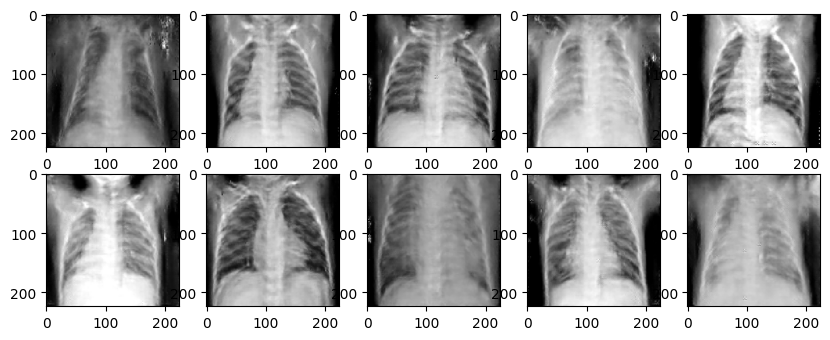

In [13]:
# Visualize first 10 images from train_ds
images, labels = next(iter(train_ds))
plt.figure(figsize=(10,10))
for i in range(10):
    ax = plt.subplot(5,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.7449 - loss: 0.8500 - precision: 0.7611 - recall: 0.6582 - val_accuracy: 0.5000 - val_loss: 1.1348 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.9516 - loss: 0.5459 - precision: 0.9535 - recall: 0.9499 - val_accuracy: 0.5000 - val_loss: 1.5423 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9678 - loss: 0.4721 - precision: 0.9664 - recall: 0.9688 - val_accuracy: 0.5000 - val_loss: 1.8492 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9738 - loss: 0.4546 - precision: 0.9765 - recall: 0.9732 - val_accuracy: 0.5000 - val_loss: 1.5818 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step

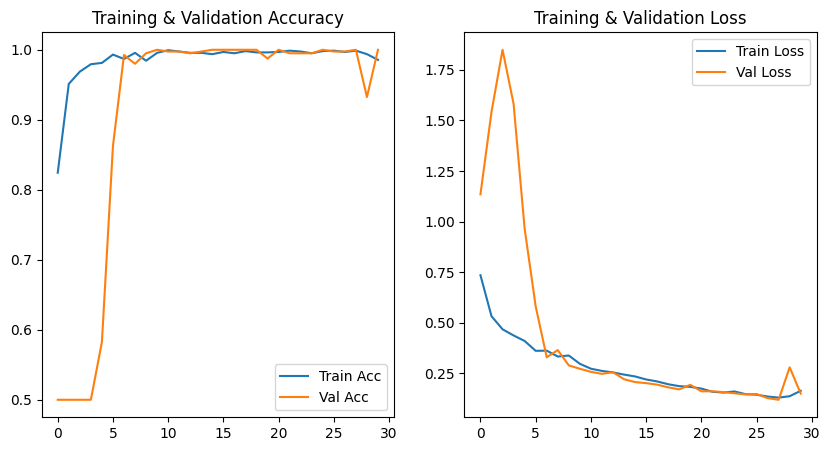

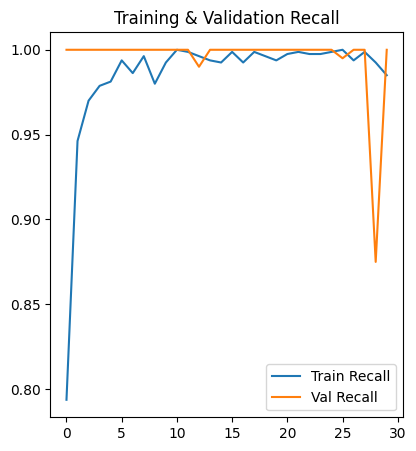

In [14]:
# Train with base cnn model
cnn_model = create_cnn()
test_description = "arc_gan"
history, y_true, y_pred, results_df = train_and_evaluate(cnn_model, train_ds, val_ds, test_ds, test_description=test_description)
plot_results(history, y_true, y_pred, test_description)

## Style GAN
The following section uses the synthetically generated images from the Style GAN. The train and validation sets are all synthetic images, while the test data comes from the original data in Kaggle. This is to help compare performance of the model on the same tests.

In [15]:
# Split synthetic data into train and validation sets
data_path = "./STYLEGAN"
output_path = "./style_gan"
load_and_split_dataset(data_path, output_path)
kaggle_data_path = "./chest_xray"

# Load and preprocess the data
test_description = "style_gan_dataset"
train_ds = load_dataset(os.path.join(output_path, "train"))
val_ds = load_dataset(os.path.join(output_path, "val"))
test_ds = load_dataset(os.path.join(kaggle_data_path, "test"))

Dataset successfully split into training and validation sets!
Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


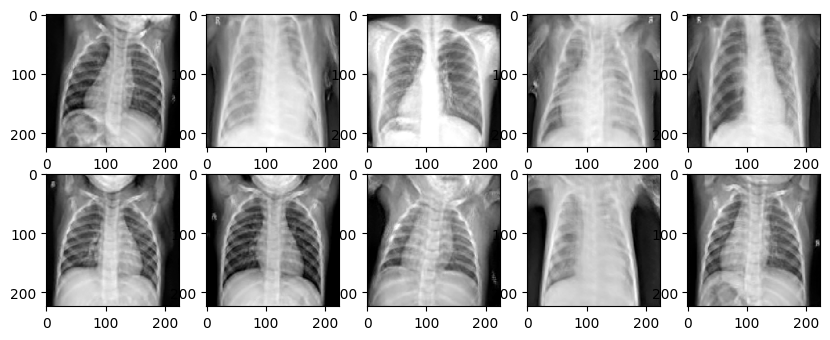

In [16]:
# Visualize first 10 images from train_ds
images, labels = next(iter(train_ds))
plt.figure(figsize=(10,10))
for i in range(10):
    ax = plt.subplot(5,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.8227 - loss: 0.7492 - precision: 0.8342 - recall: 0.8156 - val_accuracy: 0.5000 - val_loss: 2.5695 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9576 - loss: 0.5157 - precision: 0.9645 - recall: 0.9522 - val_accuracy: 0.5000 - val_loss: 2.7339 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9733 - loss: 0.4579 - precision: 0.9841 - recall: 0.9626 - val_accuracy: 0.5000 - val_loss: 2.0427 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9849 - loss: 0.4102 - precision: 0.9881 - recall: 0.9818 - val_accuracy: 0.5000 - val_loss: 1.5291 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━

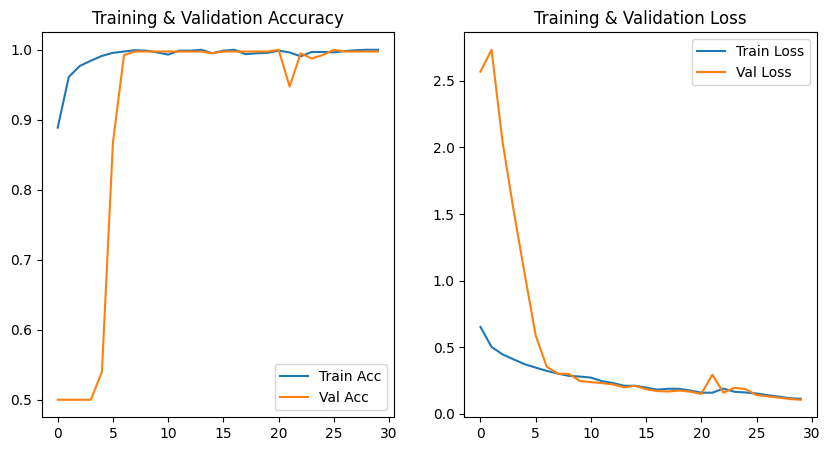

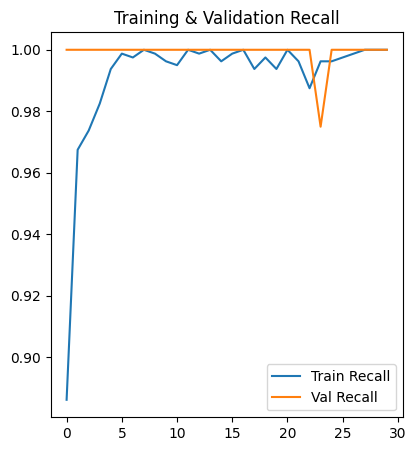

In [17]:
# Train with base cnn model
cnn_model = create_cnn()
test_description = "style_gan"
history, y_true, y_pred, results_df = train_and_evaluate(cnn_model, train_ds, val_ds, test_ds, test_description=test_description)
plot_results(history, y_true, y_pred, test_description)